In [ ]:
HI823 Final Project GMU
Create an AI system to diagnose COVID-19 using information available at home before a clinic or emergency-room visit.

It compares:

Model A: home information only
Model B: home information + at-home COVID test result
PCR Test Positive is the target in both models.

The final section builds a Bayesian network and performs probabilistic inference entirely in Python with pgmpy.

In [1]:
#Load libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, accuracy_score,
    recall_score, confusion_matrix, 
    RocCurveDisplay, ConfusionMatrixDisplay)

RANDOM_STATE = 42

In [2]:
#1. Load the three project files

# Main patient-level COVIDCARE dataset
df = pd.read_csv(r"C:\Users\Moges\Downloads\COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03.csv")

# COVIDCARE survey dictionary
dictionary = pd.read_csv(r"C:\Users\Moges\Downloads\COVIDCARE_survey_dictionary_v2_ForSubmission_MIT_Phase_II_2021-12-26.csv")

# DEMI knowledgebase
kb = pd.read_csv(r"C:\Users\Moges\Downloads\COVIDCARE_DEMI_knowledgebase_v4.csv")

# Clean column names
df.columns = df.columns.str.strip()
dictionary.columns = dictionary.columns.str.strip()
kb.columns = kb.columns.str.strip()

# Outcome variable
TARGET = "PCR Test Positive"

#verify data
print("Patient data:", df.shape)
print("Dictionary:", dictionary.shape)
print("DEMI knowledgebase:", kb.shape)

print("\nPCR outcome:")
print(df[TARGET].value_counts(dropna=False))

Patient data: (822, 472)
Dictionary: (472, 10)
DEMI knowledgebase: (70983, 11)

PCR outcome:
PCR Test Positive
0.0    501
NaN    263
1.0     58
Name: count, dtype: int64


In [3]:
#2. Use the dictionary to give the coded variables real meaning
dictionary["Variable Name"] = dictionary["Variable Name"].astype(str).str.strip()
DICT_MAP = dictionary.set_index("Variable Name").to_dict("index")

def _dict_value(var, field, default=""):
    row = DICT_MAP.get(var, {})
    value = str(row.get(field, default)).strip()
    if value.lower() == "nan" or value == "":
        return default
    return value

def description_of(var):
    return _dict_value(var, "Description", var)

def prompt_of(var):
    return _dict_value(var, "Prompt", "")

def form_of(var):
    return _dict_value(var, "Comments (Optional, Form Collection Name)", "Unknown")

def datatype_of(var):
    return _dict_value(var, "Data Type", "Unknown")

def permissible_of(var):
    return _dict_value(var, "Permisible Values", "")

print(description_of("30156-Symptom_GI-2"))

In the last 14 days,  the participant experienced the following gastrointestinal symptoms; Diarrhea


In [4]:
#3. Classify all 472 variables. Primary_Model_Use = True, identifies variables that are eligible.
#candidate predictors for the home-information-only model based on availability and temporal criteria. 
#It does not indicate that the variable is statistically important or selected by the final model.
POST_VISIT_FORMS = {
    "Follow-up Survey",
    "I Completed My In-Clinic COVID Test",
    "Confirm Your Shipping Address",
    "I Received My Testing Kit",
    "Consent",
}

PRIMARY_HOME_FORMS = {"About You", "Symptom Screening"}
AT_HOME_TEST_FORM = "At-home COVID Kit Instructions and Survey"

PRIOR_TEST_PATTERNS = [
    r"covid_result",
    r"covid_tested",
    r"covid_tst",
    r"covid_why",
    r"test_specify",
    r"test_date",
]

ADMIN_PATTERNS = [
    r"submission",
    r"confirmation",
    r"internal.?id",
    r"_deid$",
    r"email",
    r"phone",
    r"address",
    r"shipping",
    r"cohort",
]

def matches_any(text, patterns):
    text = str(text)
    return any(re.search(p, text, flags=re.I) for p in patterns)

def classify_variable(var):
    form = form_of(var)
    dtype = datatype_of(var)
    desc = description_of(var)
    prompt = prompt_of(var)
    combined = f"{var} {desc} {prompt}".lower()

    if var == TARGET:
        return "Not available at home", False, "PCR laboratory result; target only"

    if var == "PCR Test Date_DEID":
        return "Not available at home", False, "PCR outcome timing"

    if form == AT_HOME_TEST_FORM:
        return "Available at home", False, "Reserved for derived home-test feature in Model B"

    if form in POST_VISIT_FORMS:
        return "Not available at home", False, f"Excluded due to timing/form: {form}"

    if form == "Unknown":
        return "Uncertain", False, "Collection timing/form not identified"

    if form in PRIMARY_HOME_FORMS:
        if dtype.lower() == "text":
            return "Available at home", False, "Free text excluded from structured model"

        if matches_any(var, ADMIN_PATTERNS):
            return "Not available at home", False, "Administrative/date/identifier field"

        if matches_any(var, PRIOR_TEST_PATTERNS):
            return "Available at home", False, "Prior COVID testing excluded to prevent diagnostic leakage"

        if re.search(r"flu_(tst|why)", var, flags=re.I):
            return "Available at home", False, "Prior flu testing excluded"

        lab_terms = ["lab-administered", "pcr test", "antigen test", "antibody test"]
        if any(x in combined for x in lab_terms):
            return "Not available at home", False, "Laboratory/diagnostic information"

        return "Available at home", True, f"Structured pre-visit variable from {form}"

    return "Uncertain", False, f"Form not automatically assigned: {form}"

rows = []
for var in df.columns:
    status, use, reason = classify_variable(var)
    rows.append({
        "Variable": var,
        "Description": description_of(var),
        "Prompt": prompt_of(var),
        "Form": form_of(var),
        "Data_Type": datatype_of(var),
        "Permissible_Values": permissible_of(var),
        "Home_Classification": status,
        "Primary_Model_Use": use,
        "Reason": reason,
    })

classification = pd.DataFrame(rows)

print(classification["Home_Classification"].value_counts())
print("\nPrimary model use:")
print(classification["Primary_Model_Use"].value_counts())

classification.to_csv(
    "question1_dictionary_informed_variable_classification.csv",
    index=False
)

display(classification.head())

Home_Classification
Available at home        304
Not available at home    157
Uncertain                 11
Name: count, dtype: int64

Primary model use:
Primary_Model_Use
False    270
True     202
Name: count, dtype: int64


,Variable,Description,Prompt,Form,Data_Type,Permissible_Values,Home_Classification,Primary_Model_Use,Reason
0,Internal ID,Identifier for the participant to whom the res...,,Unknown,String,,Uncertain,False,Collection timing/form not identified
1,Cohort,Participant's Cohort Group of 1; 2; 3; 4; 5,,Unknown,Categorical,"1, 1; 2, 2; 3, 3; 4, 4; 5, 5",Uncertain,False,Collection timing/form not identified
2,PCR Test Positive,Participant's PCR test results,,Unknown,Categorical,"0, No; 1, Yes",Not available at home,False,PCR laboratory result; target only
3,PCR Test Date_DEID,Number of days from day of Consent when PCR Te...,,Unknown,Integer,De-identified Value in Days,Not available at home,False,PCR outcome timing
4,Consent Submission Date_DEID,This is considered as day 0 for all DEID dates,,Unknown,Integer,De-identified Value in Days,Uncertain,False,Collection timing/form not identified


In [5]:
# Make sure every Model A variable is classified as available at home
check = classification[
    classification["Primary_Model_Use"] &
    (classification["Home_Classification"] != "Available at home")
]

print("Model A variables incorrectly classified:", len(check))
display(check)

Model A variables incorrectly classified: 0


,Variable,Description,Prompt,Form,Data_Type,Permissible_Values,Home_Classification,Primary_Model_Use,Reason


In [6]:
#4. Create one clean, interpretable home-test predictor that occurred before PCR.
HOME_TEST_SPECS = [
    {
        "date": "32007-datestart_DEID",
        "positive": "30766-pinkblue_confirm",
        "negative": "30769-blue_nopink_confirm",
        "invalid": "30772-noblue_confirm",
    },
    {
        "date": "32320-datestart_2_DEID",
        "positive": "32356-pinkblue_confirm_2",
        "negative": "32359-blue_nopink_confirm_2",
        "invalid": "32362-noblue_confirm_2",
    },
]

PCR_DATE = "PCR Test Date_DEID"

def derive_home_test_result(row):
    pcr_date = row.get(PCR_DATE, np.nan)
    statuses = []

    for spec in HOME_TEST_SPECS:
        home_date = row.get(spec["date"], np.nan)

        if pd.notna(home_date) and pd.notna(pcr_date) and home_date > pcr_date:
            continue

        pos = row.get(spec["positive"], np.nan)
        neg = row.get(spec["negative"], np.nan)
        inv = row.get(spec["invalid"], np.nan)

        if pos == 1:
            statuses.append("Positive")
        elif neg == 1:
            statuses.append("Negative")
        elif inv == 1:
            statuses.append("Invalid")

    if "Positive" in statuses:
        return "Positive"
    if "Negative" in statuses:
        return "Negative"
    if "Invalid" in statuses:
        return "Invalid"
    return "Unknown"

df["HOME_TEST_RESULT_PRE_PCR"] = df.apply(derive_home_test_result, axis=1)

print(df["HOME_TEST_RESULT_PRE_PCR"].value_counts())
print("\nHome test vs PCR:")
print(pd.crosstab(df["HOME_TEST_RESULT_PRE_PCR"], df[TARGET], margins=True))

HOME_TEST_RESULT_PRE_PCR
Negative    617
Unknown     177
Positive     23
Invalid       5
Name: count, dtype: int64

Home test vs PCR:
PCR Test Positive         0.0  1.0  All
HOME_TEST_RESULT_PRE_PCR               
Invalid                     1    0    1
Negative                  431    4  435
Positive                    9    7   16
Unknown                    60   47  107
All                       501   58  559


In [7]:
#5. Create Model A and Model B datasets
#Model A — Home information only - It does not include the home-test result.
#Model B — Home information + home test

analysis_df = df[df[TARGET].isin([0, 1])].copy()
analysis_df[TARGET] = analysis_df[TARGET].astype(int)

primary_features = classification.loc[
    classification["Primary_Model_Use"], "Variable"
].tolist()

primary_features = [c for c in primary_features if c != TARGET]

def remove_unusable(data, columns, missing_threshold=0.95):
    keep = []
    removed = []

    for c in columns:
        if c not in data.columns:
            continue

        missing_rate = data[c].isna().mean()
        nunique = data[c].dropna().nunique()

        if missing_rate > missing_threshold:
            removed.append((c, "high missingness"))
        elif nunique <= 1:
            removed.append((c, "no variation"))
        else:
            keep.append(c)

    return keep, pd.DataFrame(removed, columns=["Variable", "Reason"])

primary_features, removed_features = remove_unusable(
    analysis_df, primary_features
)

MODEL_A_FEATURES = primary_features
MODEL_B_FEATURES = primary_features + ["HOME_TEST_RESULT_PRE_PCR"]

print("PCR-known patients:", len(analysis_df))
print("PCR positive:", analysis_df[TARGET].sum())
print("PCR negative:", (analysis_df[TARGET] == 0).sum())
print("Model A predictors:", len(MODEL_A_FEATURES))
print("Model B predictors:", len(MODEL_B_FEATURES))

PCR-known patients: 559
PCR positive: 58
PCR negative: 501
Model A predictors: 190
Model B predictors: 191


In [8]:
#6. Preprocessing and build three machine-learning models
#convert the survey data into something the AI algorithms can correctly analyze
def infer_feature_types(data, features):
    categorical = []
    numeric = []

    for c in features:
        if c == "HOME_TEST_RESULT_PRE_PCR":
            categorical.append(c)
            continue

        dtype = datatype_of(c).lower()

        if "categor" in dtype or "ordinal" in dtype:
            categorical.append(c)
        elif "integer" in dtype or "continuous" in dtype or "numeric" in dtype:
            numeric.append(c)
        elif data[c].dropna().nunique() <= 10:
            categorical.append(c)
        else:
            numeric.append(c)

    return categorical, numeric

def make_preprocessor(data, features):
    categorical, numeric = infer_feature_types(data, features)

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")), #handles missing data
        ("onehot", OneHotEncoder(handle_unknown="ignore")) #turns categories into separate machine-readable indicators
    ])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())   #puts continuous numeric variables on comparable scales
    ])

    prep = ColumnTransformer([
        ("cat", cat_pipe, categorical),
        ("num", num_pipe, numeric),
    ])

    return prep

# Build three machine-learning models
def build_models(data, features):
    prep = make_preprocessor(data, features)

    return {
        "Logistic": Pipeline([             #gives us a conventional baseline predictive model.
            ("prep", clone(prep)),
            ("model", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),
        "LASSO": Pipeline([                #shrink unimportant coefficients to zero
            ("prep", clone(prep)),
            ("model", LogisticRegressionCV(
                Cs=10,
                cv=5,
                penalty="l1",
                solver="saga",
                scoring="roc_auc",
                class_weight="balanced",
                max_iter=10000,
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ]),
        "Random Forest": Pipeline([        #captures more complicated nonlinear relationships and interactions
            ("prep", clone(prep)),
            ("model", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    }

In [9]:
#7. Five-fold cross-validated model evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def diagnostic_metrics(y_true, prob, threshold=0.50):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "ROC_AUC": roc_auc_score(y_true, prob),    #Overall ability to distinguish positive from negative
        "Accuracy": accuracy_score(y_true, pred),  #Overall percentage correct
        "Sensitivity": recall_score(y_true, pred),  #How many PCR-positive patients the AI detects
        "Specificity": specificity,    #How many PCR-negative patients it correctly rejects
    }

def evaluate_feature_set(data, features, label):
    X = data[features].copy()
    y = data[TARGET].astype(int)

    results = []
    predictions = {}

    for name, model in build_models(data, features).items():
        print(f"Evaluating {label}: {name}")

        prob = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=1)[:, 1]

        predictions[name] = prob   # Save probabilities for later ROC curves

        row = {"Feature_Set": label, "Model": name}
        row.update(diagnostic_metrics(y, prob))
        results.append(row)

    return pd.DataFrame(results), predictions

results_A, pred_A = evaluate_feature_set(
    analysis_df,
    MODEL_A_FEATURES,
    "Model A - Home Information"
)

results_B, pred_B = evaluate_feature_set(
    analysis_df,
    MODEL_B_FEATURES,
    "Model B - Home + Home Test"
)

model_results = pd.concat([results_A, results_B], ignore_index=True)
model_results.to_csv("question1_python_model_comparison.csv", index=False)

display(model_results.sort_values(["Feature_Set", "ROC_AUC"], ascending=[True, False]))

Evaluating Model A - Home Information: Logistic
Evaluating Model A - Home Information: LASSO
Evaluating Model A - Home Information: Random Forest
Evaluating Model B - Home + Home Test: Logistic
Evaluating Model B - Home + Home Test: LASSO
Evaluating Model B - Home + Home Test: Random Forest


,Feature_Set,Model,ROC_AUC,Accuracy,Sensitivity,Specificity
2,Model A - Home Information,Random Forest,0.878261,0.912343,0.465517,0.964072
0,Model A - Home Information,Logistic,0.810362,0.898032,0.551724,0.938124
1,Model A - Home Information,LASSO,0.805733,0.874776,0.620690,0.904192
4,Model B - Home + Home Test,LASSO,0.940860,0.880143,0.810345,0.888224
5,Model B - Home + Home Test,Random Forest,0.936179,0.932021,0.551724,0.976048
3,Model B - Home + Home Test,Logistic,0.894951,0.908766,0.672414,0.936128


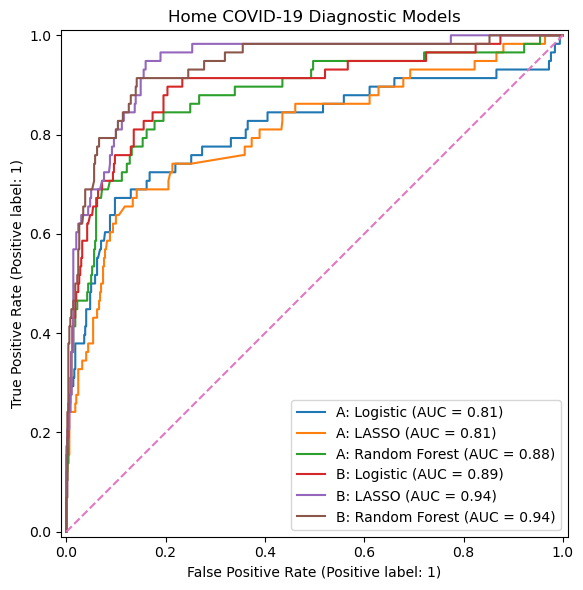

In [10]:
# ROC curves
y = analysis_df[TARGET].astype(int)

fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in pred_A.items():
    RocCurveDisplay.from_predictions(y, prob, name=f"A: {name}", ax=ax)

for name, prob in pred_B.items():
    RocCurveDisplay.from_predictions(y, prob, name=f"B: {name}", ax=ax)

ax.plot([0, 1], [0, 1], "--")
ax.set_title("Home COVID-19 Diagnostic Models")
plt.tight_layout()
plt.show()

In [11]:
#8. LASSO feature importance with real dictionary descriptions
def fit_lasso_importance(data, features):
    X = data[features].copy()
    y = data[TARGET].astype(int)

    model = build_models(data, features)["LASSO"]
    model.fit(X, y)

    prep = model.named_steps["prep"]
    fitted_lasso = model.named_steps["model"]

    names = prep.get_feature_names_out()
    coef = fitted_lasso.coef_[0]

    enc = pd.DataFrame({
        "Encoded_Feature": names,
        "Coefficient": coef,
        "Abs_Coefficient": np.abs(coef)
    })

    originals = []

    for encoded_name in names:
        if encoded_name.startswith("num__"):
            originals.append(encoded_name.replace("num__", "", 1))
            continue

        core = encoded_name.replace("cat__", "", 1)
        match = None

        for col in sorted(features, key=len, reverse=True):
            if core == col or core.startswith(col + "_"):
                match = col
                break

        originals.append(match)

    enc["Variable"] = originals
    enc = enc[enc["Variable"].notna()].copy()

    imp = (
        enc.groupby("Variable", as_index=False)
        .agg(
            LASSO_Importance=("Abs_Coefficient", "sum"),
            Max_Abs_Coefficient=("Abs_Coefficient", "max"),
            Nonzero_Levels=("Coefficient", lambda x: int((x != 0).sum()))
        )
    )

    imp["Description"] = imp["Variable"].map(description_of)
    imp["Form"] = imp["Variable"].map(form_of)

    return model, enc, imp.sort_values("LASSO_Importance", ascending=False)

lasso_A, encoded_A, importance_A = fit_lasso_importance(
    analysis_df, MODEL_A_FEATURES
)

lasso_B, encoded_B, importance_B = fit_lasso_importance(
    analysis_df, MODEL_B_FEATURES
)

importance_A.to_csv("question1_lasso_importance_model_A.csv", index=False)
importance_B.to_csv("question1_lasso_importance_model_B.csv", index=False)

print("Top 10 Model A variables")
display(importance_A.head(10))

print("Top 10 Model B variables")
display(importance_B.head(10))

Top 10 Model A variables


,Variable,LASSO_Importance,Max_Abs_Coefficient,Nonzero_Levels,Description,Form
86,30158-Symtpom_Neuro-7,0.815330,0.480042,2,"In the last 14 days, the participant experien...",Symptom Screening
138,32136-vaccine_didyou,0.543397,0.543397,1,Vaccination Status,About You
61,30153-Symptoms-6,0.446991,0.292583,2,"In the last 14 days, the participant experienc...",Symptom Screening
90,30159-Symptom_Neuro_Other,0.415714,0.415714,1,Neurological pre-existing,Symptom Screening
139,32137-vaccine_avail,0.399695,0.399695,1,Vaccination Likeliness to Receive,About You
66,30154-Symptoms_Resp-3,0.355593,0.250100,2,"In the last 14 days, the participant experien...",Symptom Screening
105,30170-Flu_shot,0.169223,0.169223,1,Flu vaccine status,Symptom Screening
29,30103-conditionsrisks-20,0.149015,0.112655,2,Following underlying conditions or risk factor...,About You
72,30155-Symptom_Resp_other,0.074139,0.074139,1,Respiratory pre-existing,Symptom Screening
98,30166-Prev_exposure-1,0.032953,0.032953,1,"In the last 14 days, the participant lived wit...",Symptom Screening


Top 10 Model B variables


,Variable,LASSO_Importance,Max_Abs_Coefficient,Nonzero_Levels,Description,Form
190,HOME_TEST_RESULT_PRE_PCR,3.978644,3.978644,1,HOME_TEST_RESULT_PRE_PCR,Unknown
87,30158-Symtpom_Neuro-8,1.552631,1.022580,2,"In the last 14 days, the participant experien...",Symptom Screening
1,30075-Other_household,1.350842,1.162436,2,Total number of other people living in partici...,About You
22,30103-conditionsrisks-13,1.061843,0.729587,2,Following underlying conditions or risk factor...,About You
138,32136-vaccine_didyou,0.927380,0.927380,1,Vaccination Status,About You
19,30101-ace_medication,0.913390,0.913390,1,ACE medication details,About You
98,30166-Prev_exposure-1,0.726279,0.600877,2,"In the last 14 days, the participant lived wit...",Symptom Screening
139,32137-vaccine_avail,0.631101,0.421801,3,Vaccination Likeliness to Receive,About You
86,30158-Symtpom_Neuro-7,0.598380,0.505818,2,"In the last 14 days, the participant experien...",Symptom Screening
107,30172-COVID_vaccine_type,0.517572,0.517572,1,2-dose type vaccine received,Symptom Screening


In [12]:
# 8. LASSO feature importance with short dictionary descriptions

def short_description(var):
    """
    Create a shorter, more readable description from the survey dictionary.
    For checkbox-style variables, the specific symptom/condition is usually
    at the end after ';' or '?'.
    """

    desc = description_of(var)
    prompt = prompt_of(var)

    # Special label for the derived home-test variable
    if var == "HOME_TEST_RESULT_PRE_PCR":
        return "At-home COVID test result"

    # Prefer the prompt when available because it often ends
    # with the specific symptom/condition.
    text = prompt if prompt else desc

    # Example:
    # "In the last 14 days, did you experience any of the following
    # neurological symptoms? Loss of taste"
    if "?" in text:
        specific = text.split("?")[-1].strip()
        if specific:
            return specific

    # Example:
    # "... symptoms selected; Fever or feeling feverish"
    if ";" in text:
        specific = text.split(";")[-1].strip()
        if specific:
            return specific

    # If neither delimiter works, return the full description
    return desc


def fit_lasso_importance(data, features):

    X = data[features].copy()
    y = data[TARGET].astype(int)

    # Fit LASSO model
    model = build_models(data, features)["LASSO"]
    model.fit(X, y)

    # Retrieve preprocessing and fitted LASSO model
    prep = model.named_steps["prep"]
    fitted_lasso = model.named_steps["model"]

    # Get encoded feature names and coefficients
    names = prep.get_feature_names_out()
    coef = fitted_lasso.coef_[0]

    # Table of encoded features
    enc = pd.DataFrame({
        "Encoded_Feature": names,
        "Coefficient": coef,
        "Abs_Coefficient": np.abs(coef)
    })

    # Map encoded features back to their original survey variables
    originals = []

    for encoded_name in names:

        # Numeric variables
        if encoded_name.startswith("num__"):
            originals.append(
                encoded_name.replace("num__", "", 1)
            )
            continue

        # Categorical variables
        core = encoded_name.replace("cat__", "", 1)

        match = None

        for col in sorted(features, key=len, reverse=True):
            if core == col or core.startswith(col + "_"):
                match = col
                break

        originals.append(match)

    enc["Variable"] = originals

    # Remove any features that could not be matched
    enc = enc[
        enc["Variable"].notna()
    ].copy()

    # Aggregate encoded coefficients back to original variables
    imp = (
        enc.groupby("Variable", as_index=False)
        .agg(
            LASSO_Importance=(
                "Abs_Coefficient",
                "sum"
            )
        )
    )

    # Add readable short descriptions
    imp["Short_Description"] = (
        imp["Variable"]
        .map(short_description)
    )

    # Rank from most to least important
    imp = imp.sort_values(
        "LASSO_Importance",
        ascending=False
    )

    return model, enc, imp

# MODEL A
# Home information only

lasso_A, encoded_A, importance_A = (
    fit_lasso_importance(
        analysis_df,
        MODEL_A_FEATURES
    )
)

# MODEL B
# Home information + home test

lasso_B, encoded_B, importance_B = (
    fit_lasso_importance(
        analysis_df,
        MODEL_B_FEATURES
    )
)

# Save complete importance tables
importance_A.to_csv(
    "question1_lasso_importance_model_A.csv",
    index=False
)

importance_B.to_csv(
    "question1_lasso_importance_model_B.csv",
    index=False
)

# DISPLAY TOP 10

print("Top 10 Model A variables")

display(
    importance_A[
        [
            "Variable",
            "Short_Description",
            "LASSO_Importance"
        ]
    ].head(10)
)
print("\nTop 10 Model B variables")

display(
    importance_B[
        [
            "Variable",
            "Short_Description",
            "LASSO_Importance"
        ]
    ].head(10)
)

Top 10 Model A variables


,Variable,Short_Description,LASSO_Importance
86,30158-Symtpom_Neuro-7,Loss of smell,0.815330
138,32136-vaccine_didyou,Vaccination Status,0.543397
61,30153-Symptoms-6,Chills,0.446991
90,30159-Symptom_Neuro_Other,Neurological pre-existing,0.415714
139,32137-vaccine_avail,Vaccination Likeliness to Receive,0.399695
66,30154-Symptoms_Resp-3,Cough,0.355593
105,30170-Flu_shot,Flu vaccine status,0.169223
29,30103-conditionsrisks-20,I do not have any underlying conditions or ris...,0.149015
72,30155-Symptom_Resp_other,Respiratory pre-existing,0.074139
98,30166-Prev_exposure-1,No,0.032953



Top 10 Model B variables


,Variable,Short_Description,LASSO_Importance
190,HOME_TEST_RESULT_PRE_PCR,At-home COVID test result,3.978644
87,30158-Symtpom_Neuro-8,Loss of taste,1.552631
1,30075-Other_household,Please enter the number below.,1.350842
22,30103-conditionsrisks-13,"Mental Health conditions, including serious me...",1.061843
138,32136-vaccine_didyou,Vaccination Status,0.927380
19,30101-ace_medication,ACE medication details,0.913390
98,30166-Prev_exposure-1,No,0.726279
139,32137-vaccine_avail,Vaccination Likeliness to Receive,0.631101
86,30158-Symtpom_Neuro-7,Loss of smell,0.598380
107,30172-COVID_vaccine_type,2-dose type vaccine received,0.517572


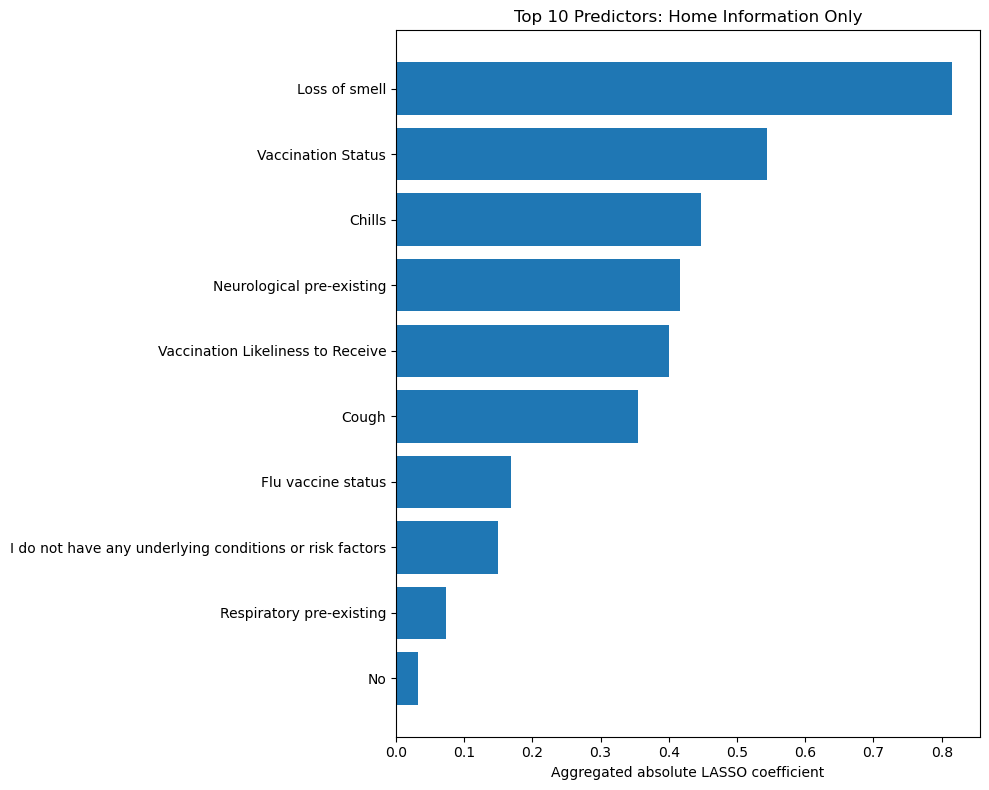

In [13]:
#rank top 10 most important LASSO predictors in Model A
top_plot_A = importance_A.head(10).sort_values("LASSO_Importance")

plt.figure(figsize=(10, 8))
plt.barh(top_plot_A["Short_Description"], top_plot_A["LASSO_Importance"])
plt.xlabel("Aggregated absolute LASSO coefficient")
plt.title("Top 10 Predictors: Home Information Only")
plt.tight_layout()
plt.show()

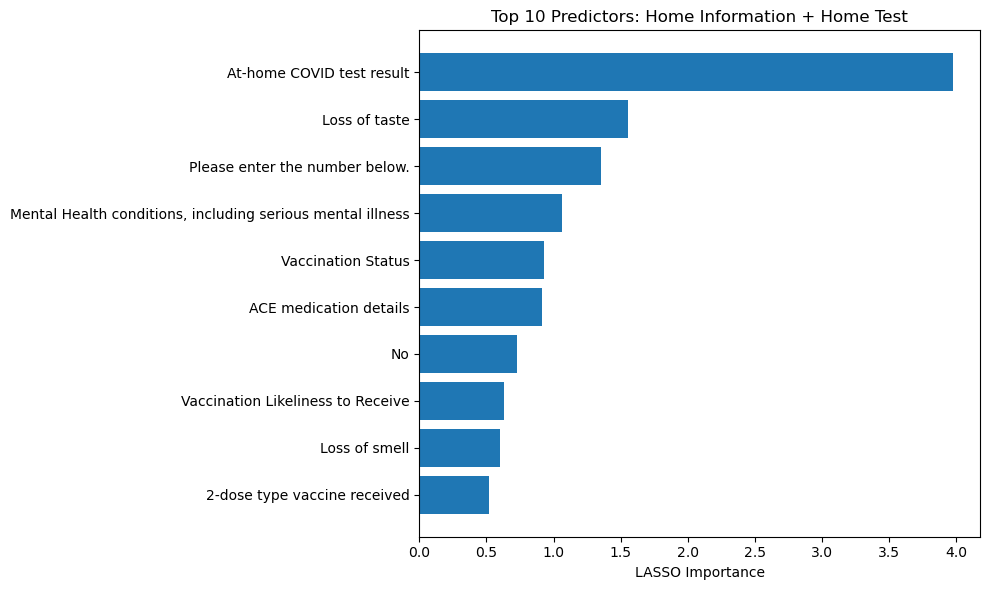

In [14]:
#rank top 10 most important LASSO predictors in Model B
top_plot_B = importance_B.head(10).sort_values("LASSO_Importance")

plt.figure(figsize=(10, 6))

plt.barh(top_plot_B["Short_Description"],top_plot_B["LASSO_Importance"])

plt.xlabel("LASSO Importance")
plt.title("Top 10 Predictors: Home Information + Home Test")

plt.tight_layout()
plt.show()

In [15]:
#9. Bayesian-network predictors
TOP_N_BN = 10

bn_candidates = importance_B[
    (importance_B["LASSO_Importance"] > 0) &
    (importance_B["Variable"].isin(MODEL_B_FEATURES))
].copy()

BN_FEATURES = bn_candidates.head(TOP_N_BN)["Variable"].tolist()

print("Bayesian-network predictors:")
for i, v in enumerate(BN_FEATURES, 1):
    print(f"{i:2d}. {v} -> {short_description(v)}")

Bayesian-network predictors:
 1. HOME_TEST_RESULT_PRE_PCR -> At-home COVID test result
 2. 30158-Symtpom_Neuro-8 -> Loss of taste
 3. 30075-Other_household -> Please enter the number below.
 4. 30103-conditionsrisks-13 -> Mental Health conditions, including serious mental illness
 5. 32136-vaccine_didyou -> Vaccination Status
 6. 30101-ace_medication -> ACE medication details
 7. 30166-Prev_exposure-1 -> No
 8. 32137-vaccine_avail -> Vaccination Likeliness to Receive
 9. 30158-Symtpom_Neuro-7 -> Loss of smell
10. 30172-COVID_vaccine_type -> 2-dose type vaccine received


In [16]:
#10. Discretize selected variables for Bayesian CPDs,conditional probability distributions
#prepare the dataset specifically for Bayesian-network estimation
def discretize_for_bn(series, variable):
    s = series.copy()
    dtype = datatype_of(variable).lower()
    nonmissing = s.dropna()

    if "categor" in dtype or "ordinal" in dtype or nonmissing.nunique() <= 8:
        return s.fillna("Unknown").astype(str)

    numeric = pd.to_numeric(s, errors="coerce")

    if numeric.dropna().nunique() >= 3:
        try:
            binned = pd.qcut(
                numeric,
                q=3,
                labels=["Low", "Medium", "High"],
                duplicates="drop"
            )
            return binned.astype(object).where(
                binned.notna(), "Unknown"
            ).astype(str)
        except Exception:
            pass

    return numeric.fillna(numeric.median()).round(0).astype(str)

bn_data = pd.DataFrame(index=analysis_df.index)

for v in BN_FEATURES:
    bn_data[v] = discretize_for_bn(analysis_df[v], v)

bn_data[TARGET] = analysis_df[TARGET].astype(int).astype(str)

display(bn_data.head())

,HOME_TEST_RESULT_PRE_PCR,30158-Symtpom_Neuro-8,30075-Other_household,30103-conditionsrisks-13,32136-vaccine_didyou,30101-ace_medication,30166-Prev_exposure-1,32137-vaccine_avail,30158-Symtpom_Neuro-7,30172-COVID_vaccine_type,PCR Test Positive
0,Negative,0.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0
1,Negative,0.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0
2,Negative,0.0,2.0,0.0,1.0,2.0,1.0,0.0,0.0,1.0,0
3,Negative,1.0,6.0,0.0,1.0,2.0,1.0,0.0,1.0,1.0,0
4,Negative,0.0,4.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0


In [17]:
#11. Use DEMI pairwise temporal evidence to orient predictor-predictor edges
def demi_candidate_edges(selected_features, kb_df):
    selected = set(selected_features)

    temp = kb_df[
        kb_df["concept_code"].isin(selected) &
        kb_df["target_concept_code"].isin(selected) &
        (kb_df["concept_code"] != kb_df["target_concept_code"])
    ].copy()

    if temp.empty:
        return pd.DataFrame(
            columns=["source", "target", "temporal_strength", "association_strength"]
        )

    n11 = temp["n_code_target"].astype(float)
    n10 = temp["n_code_no_target"].astype(float)
    n01 = temp["n_target_no_code"].astype(float)
    n00 = temp["n_no_code_no_target"].astype(float)

    num = n11 * n00 - n10 * n01
    den = np.sqrt((n11+n10)*(n01+n00)*(n11+n01)*(n10+n00))

    temp["phi"] = np.where(den > 0, num / den, 0)

    cb = temp["n_code_before_target"].fillna(0).astype(float)
    tb = temp["n_target_before_code"].fillna(0).astype(float)

    temp["source"] = np.where(
        cb >= tb,
        temp["concept_code"],
        temp["target_concept_code"]
    )

    temp["target"] = np.where(
        cb >= tb,
        temp["target_concept_code"],
        temp["concept_code"]
    )

    temp["temporal_strength"] = np.maximum(cb, tb)
    temp["association_strength"] = temp["phi"].abs()

    return (
        temp.sort_values(
            ["temporal_strength", "association_strength"],
            ascending=False
        )
        .drop_duplicates(["source", "target"])
        [["source", "target", "temporal_strength", "association_strength"]]
    )

demi_edges = demi_candidate_edges(BN_FEATURES, kb)
display(demi_edges.head(20))

,source,target,temporal_strength,association_strength
27233,30166-Prev_exposure-1,30158-Symtpom_Neuro-8,560.0,0.140106
26998,30166-Prev_exposure-1,30158-Symtpom_Neuro-7,556.0,0.161291
4203,30166-Prev_exposure-1,30103-conditionsrisks-13,522.0,0.057883
4194,30103-conditionsrisks-13,30158-Symtpom_Neuro-8,59.0,0.008508
4193,30103-conditionsrisks-13,30158-Symtpom_Neuro-7,59.0,0.007328
26989,30158-Symtpom_Neuro-7,30158-Symtpom_Neuro-8,12.0,0.771618


In [18]:
#Create the DAG,directed acyclic graph
MAX_PREDICTOR_PARENTS = 2

G = nx.DiGraph()
G.add_nodes_from(BN_FEATURES + [TARGET])

for _, row in demi_edges.iterrows():
    source = row["source"]
    target = row["target"]

    if source == target:
        continue

    if G.in_degree(target) >= MAX_PREDICTOR_PARENTS:
        continue

    G.add_edge(source, target)

    if not nx.is_directed_acyclic_graph(G):
        G.remove_edge(source, target)

# Selected home predictors directly predict PCR.
for v in BN_FEATURES:
    G.add_edge(v, TARGET)

assert nx.is_directed_acyclic_graph(G)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

#for parent, child in G.edges():
    #print(parent, "->", child)

print("\nDAG relationships:")

for parent, child in G.edges():

    parent_label = (
        "PCR Test Positive"
        if parent == TARGET
        else short_description(parent)
    )

    child_label = (
        "PCR Test Positive"
        if child == TARGET
        else short_description(child)
    )

    print(parent_label, "->", child_label)

Nodes: 11
Edges: 15

DAG relationships:
At-home COVID test result -> PCR Test Positive
Loss of taste -> PCR Test Positive
Please enter the number below. -> PCR Test Positive
Mental Health conditions, including serious mental illness -> Loss of taste
Mental Health conditions, including serious mental illness -> Loss of smell
Mental Health conditions, including serious mental illness -> PCR Test Positive
Vaccination Status -> PCR Test Positive
ACE medication details -> PCR Test Positive
No -> Loss of taste
No -> Loss of smell
No -> Mental Health conditions, including serious mental illness
No -> PCR Test Positive
Vaccination Likeliness to Receive -> PCR Test Positive
Loss of smell -> PCR Test Positive
2-dose type vaccine received -> PCR Test Positive


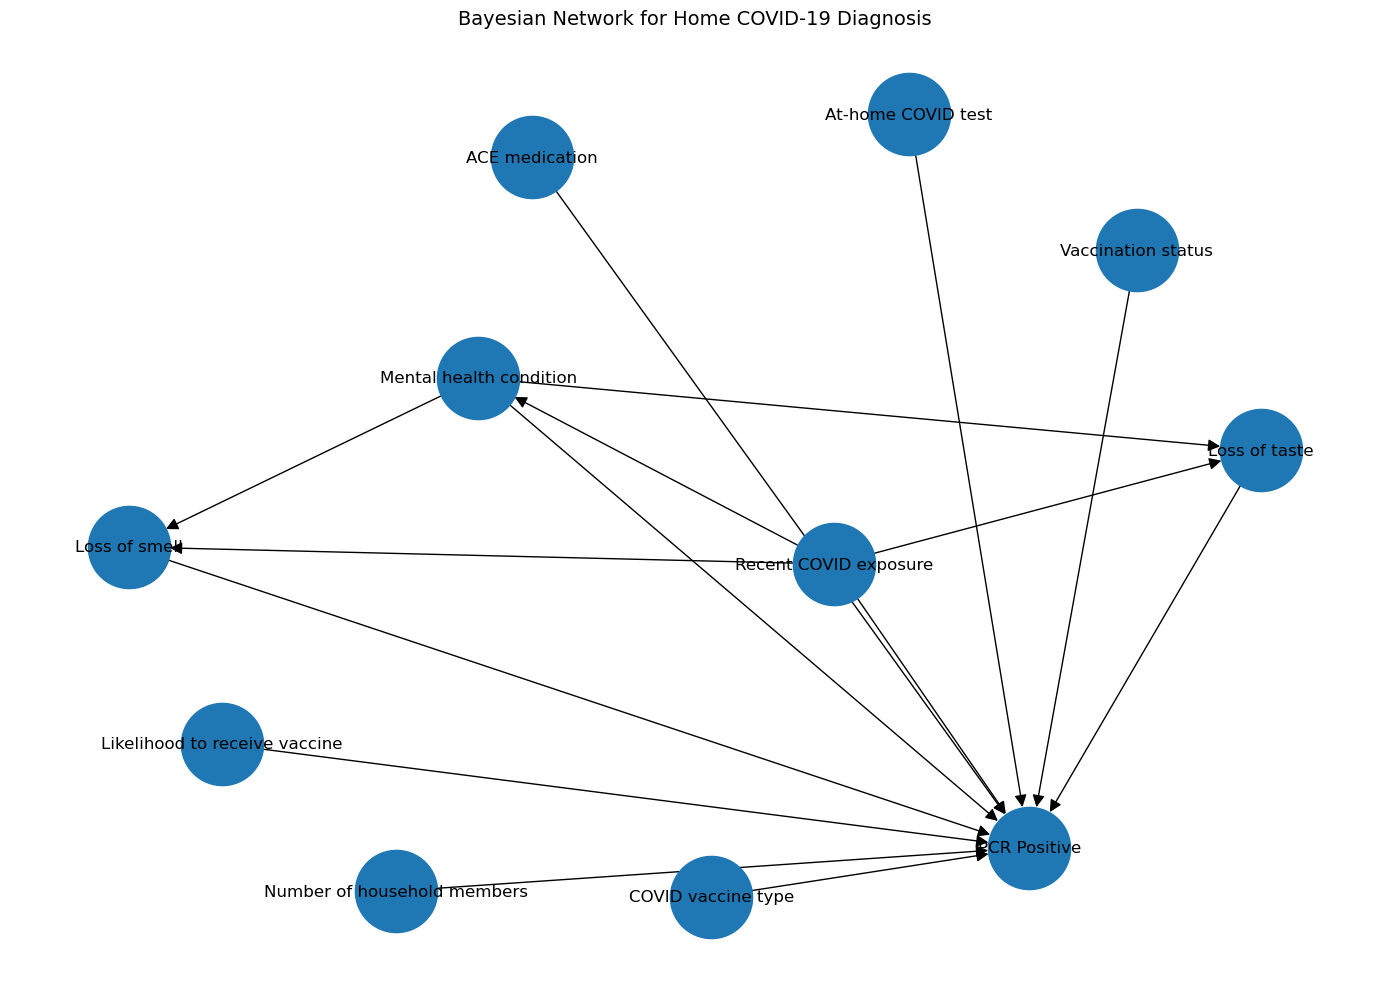

In [29]:
# Drawing the Bayesian network using short, readable descriptions
plt.figure(figsize=(14, 10))

# Position nodes
pos = nx.spring_layout(G,seed=RANDOM_STATE,k=1.8)

# Create readable labels without changing the actual node names
labels = {
    node: ("PCR Positive"
        if node == TARGET
        else short_description(node)
    )
    for node in G.nodes()
}

# Manually clean a few labels that are still unclear
label_overrides = {
    "HOME_TEST_RESULT_PRE_PCR": "At-home COVID test",
    "30075-Other_household": "Number of household members",
    "30166-Prev_exposure-1": "Recent COVID exposure",
    "30103-conditionsrisks-13": "Mental health condition",
    "32136-vaccine_didyou": "Vaccination status",
    "32137-vaccine_avail": "Likelihood to receive vaccine",
    "30101-ace_medication": "ACE medication",
    "30158-Symtpom_Neuro-7": "Loss of smell",
    "30158-Symtpom_Neuro-8": "Loss of taste",
    "30172-COVID_vaccine_type": "COVID vaccine type"
}
# Apply the cleaner labels only for visualization
for variable, clean_label in label_overrides.items():
    if variable in labels:
        labels[variable] = clean_label

# Draw network
nx.draw_networkx(
    G,
    pos,
    labels=labels,
    node_size=3500,
    font_size=12,
    arrows=True,
    arrowsize=18
)

plt.title(
    "Bayesian Network for Home COVID-19 Diagnosis",
    fontsize=14
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
#Fit CPDs and run Bayesian inference in Python
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

# Create Bayesian Network from the DAG edges
bn_model = DiscreteBayesianNetwork(list(G.edges()))

# Make sure all nodes are included
for node in G.nodes():
    if node not in bn_model.nodes():
        bn_model.add_node(node)

# Estimate CPDs using BayesianEstimator
estimator = BayesianEstimator(
    bn_model,
    bn_data[BN_FEATURES + [TARGET]]
)

cpds = estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=10
)

# Add estimated CPDs to the network
bn_model.add_cpds(*cpds)

# Check model
print("Model valid:", bn_model.check_model())
print("Number of CPDs:", len(bn_model.get_cpds()))

# Display direct predictors of PCR
print("\nDirect parents of PCR:")

for parent in bn_model.get_parents(TARGET):
    print("-", short_description(parent))

Model valid: True
Number of CPDs: 11

Direct parents of PCR:
- At-home COVID test result
- Loss of taste
- Please enter the number below.
- Mental Health conditions, including serious mental illness
- Vaccination Status
- ACE medication details
- No
- Vaccination Likeliness to Receive
- Loss of smell
- 2-dose type vaccine received


In [22]:
#Bayesian inference - diagnostic AI system
state_table = pd.DataFrame({
    "Variable": BN_FEATURES,
    "Description": [short_description(v) for v in BN_FEATURES],
    "Allowed_States": [
        ", ".join(sorted(bn_data[v].astype(str).unique()))
        for v in BN_FEATURES
    ]
})

display(state_table)

inference = VariableElimination(bn_model)

def covid_probability(evidence):
    clean = {}

    for variable, state in evidence.items():
        if variable not in BN_FEATURES:
            raise ValueError(f"{variable} is not in the Bayesian network.")

        allowed = set(bn_data[variable].astype(str).unique())
        state = str(state)

        if state not in allowed:
            raise ValueError(
                f"Invalid state {state} for {variable}. Allowed: {sorted(allowed)}"
            )

        clean[variable] = state

    result = inference.query(
        variables=[TARGET],
        evidence=clean,
        show_progress=False
    )

    states = [str(x) for x in result.state_names[TARGET]]
    prob_map = dict(zip(states, result.values))

    return prob_map.get("1", prob_map.get("1.0", np.nan))

# Example using observed evidence from the first PCR-known participant
example_index = bn_data.index[0]

example_evidence = {
    v: bn_data.loc[example_index, v]
    for v in BN_FEATURES[:5]
}

print("Example evidence:")
for v, state in example_evidence.items():
    print(short_description(v), "=", state)

p = covid_probability(example_evidence)
print(f"\nEstimated P(PCR positive | home evidence) = {p:.3f}")

,Variable,Description,Allowed_States
0,HOME_TEST_RESULT_PRE_PCR,At-home COVID test result,"Invalid, Negative, Positive, Unknown"
1,30158-Symtpom_Neuro-8,Loss of taste,"0.0, 1.0, Unknown"
2,30075-Other_household,Please enter the number below.,"1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 999.0, Unknown"
3,30103-conditionsrisks-13,"Mental Health conditions, including serious me...","0.0, 1.0, Unknown"
4,32136-vaccine_didyou,Vaccination Status,"1.0, 2.0, 999.0, Unknown"
5,30101-ace_medication,ACE medication details,"1.0, 2.0, 999.0, Unknown"
6,30166-Prev_exposure-1,No,"0.0, 1.0, Unknown"
7,32137-vaccine_avail,Vaccination Likeliness to Receive,"0.0, 14.0, 15.0, 16.0, 17.0, 18.0, Unknown"
8,30158-Symtpom_Neuro-7,Loss of smell,"0.0, 1.0, Unknown"
9,30172-COVID_vaccine_type,2-dose type vaccine received,"0.0, 1.0, 2.0, 3.0, Unknown"


Example evidence:
At-home COVID test result = Negative
Loss of taste = 0.0
Please enter the number below. = 2.0
Mental Health conditions, including serious mental illness = 0.0
Vaccination Status = 1.0

Estimated P(PCR positive | home evidence) = 0.176


In [23]:
example_index = bn_data.index[10]

example_evidence = {
    v: bn_data.loc[example_index, v]
    for v in BN_FEATURES
}

p = covid_probability(example_evidence)

actual_pcr = bn_data.loc[
    example_index,
    TARGET
]

print("Patient evidence:")
for v, state in example_evidence.items():
    print(short_description(v), "=", state)

print(
    f"\nPredicted probability of PCR positive = {p:.3f}"
)

print(
    f"Actual PCR result = {actual_pcr}"
)

Patient evidence:
At-home COVID test result = Negative
Loss of taste = 0.0
Please enter the number below. = 3.0
Mental Health conditions, including serious mental illness = 1.0
Vaccination Status = 1.0
ACE medication details = 1.0
No = 1.0
Vaccination Likeliness to Receive = 0.0
Loss of smell = 0.0
2-dose type vaccine received = 2.0

Predicted probability of PCR positive = 0.000
Actual PCR result = 0


In [24]:
base_evidence = {
    "30158-Symtpom_Neuro-7": "1.0",
    "30166-Prev_exposure-1": "1.0",
    "32136-vaccine_didyou": "1.0"
}

# No home test
p_no_test = covid_probability(base_evidence)

# Negative home test
negative_evidence = base_evidence.copy()
negative_evidence["HOME_TEST_RESULT_PRE_PCR"] = "Negative"

p_negative = covid_probability(
    negative_evidence
)

# Positive home test
positive_evidence = base_evidence.copy()
positive_evidence["HOME_TEST_RESULT_PRE_PCR"] = "Positive"

p_positive = covid_probability(
    positive_evidence
)

print("No home test:", round(p_no_test, 3))
print("Negative home test:", round(p_negative, 3))
print("Positive home test:", round(p_positive, 3))

No home test: 0.475
Negative home test: 0.462
Positive home test: 0.5


In [25]:
print("Direct parents of PCR:")
for parent in bn_model.get_parents(TARGET):
    print("-", short_description(parent))

Direct parents of PCR:
- At-home COVID test result
- Loss of taste
- Please enter the number below.
- Mental Health conditions, including serious mental illness
- Vaccination Status
- ACE medication details
- No
- Vaccination Likeliness to Receive
- Loss of smell
- 2-dose type vaccine received


In [26]:
print("Direct parents of PCR:\n")

for parent in bn_model.get_parents(TARGET):
    print(
        parent,
        "->",
        short_description(parent)
    )

Direct parents of PCR:

HOME_TEST_RESULT_PRE_PCR -> At-home COVID test result
30158-Symtpom_Neuro-8 -> Loss of taste
30075-Other_household -> Please enter the number below.
30103-conditionsrisks-13 -> Mental Health conditions, including serious mental illness
32136-vaccine_didyou -> Vaccination Status
30101-ace_medication -> ACE medication details
30166-Prev_exposure-1 -> No
32137-vaccine_avail -> Vaccination Likeliness to Receive
30158-Symtpom_Neuro-7 -> Loss of smell
30172-COVID_vaccine_type -> 2-dose type vaccine received
